In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')

from collections import Counter

import gzip
import pickle
from pathlib import Path

from ase import Atoms
from ase.io import read, write
from ase.visualize import view
from ase.formula import Formula

from pprint import pprint

import ternary
import plotly.express as px
import plotly.graph_objects as go

In [43]:
with gzip.open("20260223.pkl.gzip", "rb") as f:
    data = pickle.load(f)

data["name"] = data["name"].str.removeprefix("/nfshome/sicolo/work/MLIP/dft_db/")
data["name"] = data["name"].str.removesuffix("/OUTCAR##0")
data["type"] = data["name"].str.split("/").str[0]
data["type"] = data["type"].str.replace("_", " ")

data.tail()

,name,ase_atoms,energy,forces,stress,results,energy_corrected,energy_corrected_per_atom,type
2250,binary_phases/Ni6O7/s1030_k001,"(Atom('Ni', [np.float64(3.01337), np.float64(-...",-247.768943,"[[0.00172, -0.233691, -0.304158], [-0.256487, ...","[0.06262595440314142, 0.06187333450821504, 0.1...","{'magmom': 20.0000001, 'magmoms': [1.623, 1.64...",-124.381311,-4.783897,binary phases
2251,binary_phases/Ni6O7/s1040_k000,"(Atom('Ni', [np.float64(3.13117), np.float64(-...",-246.346503,"[[0.245007, -0.097249, -0.129805], [-0.27556, ...","[0.16435100012164652, 0.1391575479916028, 0.10...","{'magmom': 20.0000001, 'magmoms': [1.611, 1.61...",-122.958871,-4.729187,binary phases
2252,binary_phases/Ni6O7/s1040_k001,"(Atom('Ni', [np.float64(2.95003), np.float64(-...",-247.981254,"[[-0.039462, 0.00916, -0.112752], [-0.414722, ...","[0.05887237947143561, 0.06826490199650279, 0.1...","{'magmom': 20.0000001, 'magmoms': [1.629, 1.65...",-124.593622,-4.792062,binary phases
2253,binary_phases/Ni6O7/s1050_k000,"(Atom('Ni', [np.float64(2.85126), np.float64(-...",-247.976432,"[[0.165546, 0.083503, 0.098205], [-0.071021, -...","[0.07838813671946449, 0.10390699616929526, 0.0...","{'magmom': 20.0000001, 'magmoms': [1.613, 1.57...",-124.588800,-4.791877,binary phases
2254,binary_phases/Ni6O7/s1050_k001,"(Atom('Ni', [np.float64(3.03483), np.float64(-...",-242.520222,"[[0.26844, -0.01935, -0.194464], [-0.14426, -0...","[0.15238088412380857, 0.1687670238659371, 0.21...","{'magmom': 20.0000001, 'magmoms': [1.634, 1.64...",-119.132590,-4.582023,binary phases


In [26]:
data.shape

(2255, 9)

In [27]:
n_atoms = data["ase_atoms"].apply(len)
force_shapes_ok = data.apply(lambda r: np.asarray(r["forces"]).shape == (len(r["ase_atoms"]), 3), axis=1)

print("Atoms min/mean/median/max:", n_atoms.min(), round(n_atoms.mean()), round(n_atoms.median()), n_atoms.max())
print("Force shape ok fraction:", force_shapes_ok.mean())
print("Bad rows:", (~force_shapes_ok).sum())

Atoms min/mean/median/max: 1 46 40 128
Force shape ok fraction: 1.0
Bad rows: 0


In [28]:
data["n_atoms"] = data["ase_atoms"].apply(len)
data["formula"] = data["ase_atoms"].apply(lambda a: a.get_chemical_formula())
data["formula_red"] = data["ase_atoms"].apply(lambda a: str(Formula(a.get_chemical_formula()).reduce()[0]))

data.head()

,name,ase_atoms,energy,forces,stress,results,energy_corrected,energy_corrected_per_atom,type,n_atoms,formula,formula_red
0,ce_structures/selected/18_0.375/0000/OUTCAR##0,"(Atom('Li', [np.float64(-2.73936), np.float64(...",-225.506490,"[[0.008302, 0.014337, 6e-05], [1.5e-05, 6e-05,...","[-0.005913505338299842, -0.005637774189645697,...","{'magmom': 3.0, 'magmoms': [0.009, 0.009, 0.00...",-121.388465,-4.495869,ce structures,27,Li3Ni8O16,Li3Ni8O16
1,ce_structures/selected/18_0.375/s0950_k000/OUT...,"(Atom('Li', [np.float64(1.60487), np.float64(-...",-220.157903,"[[-0.092948, -0.169861, 0.11735], [0.015319, 0...","[-0.2814075827513161, -0.3119029721894691, -0....","{'magmom': 3.0, 'magmoms': [0.009, 0.009, 0.00...",-116.039877,-4.297773,ce structures,27,Li3Ni8O16,Li3Ni8O16
2,ce_structures/selected/18_0.375/s0950_k001/OUT...,"(Atom('Li', [np.float64(0.05328), np.float64(0...",-212.712001,"[[0.077629, -0.25681, -0.284935], [0.00216, 0....","[-0.541944570110157, -0.652920618375809, -0.39...","{'magmom': 3.0, 'magmoms': [0.011, 0.012, 0.01...",-108.593975,-4.021999,ce structures,27,Li3Ni8O16,Li3Ni8O16
3,ce_structures/selected/18_0.375/s0960_k000/OUT...,"(Atom('Li', [np.float64(-3.88834), np.float64(...",-209.283534,"[[-0.323024, -0.089433, 0.278154], [0.043983, ...","[-0.7515230245956165, -0.4900357986799055, -0....","{'magmom': 3.0, 'magmoms': [0.01, 0.01, 0.01, ...",-105.165508,-3.895019,ce structures,27,Li3Ni8O16,Li3Ni8O16
4,ce_structures/selected/18_0.375/s0960_k001/OUT...,"(Atom('Li', [np.float64(0.05249), np.float64(0...",-220.572119,"[[-0.009643, -0.255397, -0.089572], [-0.029939...","[-0.29187823235524274, -0.2374463620683985, -0...","{'magmom': 3.0, 'magmoms': [0.011, 0.011, 0.01...",-116.454094,-4.313115,ce structures,27,Li3Ni8O16,Li3Ni8O16


In [29]:
def get_ratios(atoms):
    symbols = atoms.get_chemical_symbols()
    
    n_Ni = symbols.count("Ni")
    n_O  = symbols.count("O")
    n_Li = symbols.count("Li")
    
    # Avoid division by zero like a responsible adult
    ni_o_ratio = n_Ni / n_O if n_O > 0 else np.nan
    li_ni_ratio = n_Li / n_Ni if n_Ni > 0 else np.nan
    
    return pd.Series([ni_o_ratio, li_ni_ratio])

data[["Ni_O_ratio", "Li_Ni_ratio"]] = data["ase_atoms"].apply(get_ratios)

In [30]:
data.head()

,name,ase_atoms,energy,forces,stress,results,energy_corrected,energy_corrected_per_atom,type,n_atoms,formula,formula_red,Ni_O_ratio,Li_Ni_ratio
0,ce_structures/selected/18_0.375/0000/OUTCAR##0,"(Atom('Li', [np.float64(-2.73936), np.float64(...",-225.506490,"[[0.008302, 0.014337, 6e-05], [1.5e-05, 6e-05,...","[-0.005913505338299842, -0.005637774189645697,...","{'magmom': 3.0, 'magmoms': [0.009, 0.009, 0.00...",-121.388465,-4.495869,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375
1,ce_structures/selected/18_0.375/s0950_k000/OUT...,"(Atom('Li', [np.float64(1.60487), np.float64(-...",-220.157903,"[[-0.092948, -0.169861, 0.11735], [0.015319, 0...","[-0.2814075827513161, -0.3119029721894691, -0....","{'magmom': 3.0, 'magmoms': [0.009, 0.009, 0.00...",-116.039877,-4.297773,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375
2,ce_structures/selected/18_0.375/s0950_k001/OUT...,"(Atom('Li', [np.float64(0.05328), np.float64(0...",-212.712001,"[[0.077629, -0.25681, -0.284935], [0.00216, 0....","[-0.541944570110157, -0.652920618375809, -0.39...","{'magmom': 3.0, 'magmoms': [0.011, 0.012, 0.01...",-108.593975,-4.021999,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375
3,ce_structures/selected/18_0.375/s0960_k000/OUT...,"(Atom('Li', [np.float64(-3.88834), np.float64(...",-209.283534,"[[-0.323024, -0.089433, 0.278154], [0.043983, ...","[-0.7515230245956165, -0.4900357986799055, -0....","{'magmom': 3.0, 'magmoms': [0.01, 0.01, 0.01, ...",-105.165508,-3.895019,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375
4,ce_structures/selected/18_0.375/s0960_k001/OUT...,"(Atom('Li', [np.float64(0.05249), np.float64(0...",-220.572119,"[[-0.009643, -0.255397, -0.089572], [-0.029939...","[-0.29187823235524274, -0.2374463620683985, -0...","{'magmom': 3.0, 'magmoms': [0.011, 0.011, 0.01...",-116.454094,-4.313115,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375


In [31]:
data['formula'].unique()

<StringArray>
[  'Li3Ni8O16',    'LiNi8O16',   'Li2Ni9O18',    'LiNi9O18',  'Li3Ni10O20',
  'Li2Ni10O20',  'Li7Ni10O20',   'LiNi10O20',  'Li4Ni11O22',  'Li3Ni11O22',
  'Li2Ni11O22',   'LiNi11O22',  'Li5Ni12O24',   'LiNi12O24', 'Li11Ni12O24',
 'Li10Ni12O24',  'Li7Ni12O24',  'Li8Ni12O24',  'Li2Ni12O24',   'LiNi15O30',
  'Li3Ni13O26',  'Li5Ni15O30',  'Li2Ni13O26',   'LiNi13O26',  'Li4Ni13O26',
  'Li4Ni14O28',  'Li3Ni14O28',  'Li2Ni14O28',   'LiNi14O28',  'Li4Ni15O30',
  'Li3Ni15O30',  'Li2Ni15O30',     'Ni27O54',     'Ni27O53', 'Li27Ni27O54',
 'Li27Ni27O53',   'Li6Ni6O12',  'Li8Ni32O64',  'Li8Ni20O40',  'Li8Ni16O32',
 'Li20Ni32O64', 'Li24Ni32O64',   'Li8Ni8O16',      'Ni8O16',     'Ni12O24',
 'Li14Ni18O36', 'Li16Ni18O36', 'Li12Ni12O24', 'Li20Ni18O36', 'Li14Ni12O24',
 'Li22Ni18O36',   'Li4Ni6O12',   'Li8Ni6O12', 'Li10Ni10O16', 'Li24Ni24O48',
 'Li10Ni10O20',  'Li8Ni10O20',       'Ni3O6',      'Ni5O10',     'Ni10O20',
      'Ni6O12',     'Ni24O24',     'Ni18O18',     'Ni22O22',          'Li'

In [32]:
data['formula_red'].unique()

<StringArray>
[  'Li3Ni8O16',    'LiNi8O16',   'Li2Ni9O18',    'LiNi9O18',  'Li3Ni10O20',
    'LiNi5O10',  'Li7Ni10O20',   'LiNi10O20',  'Li4Ni11O22',  'Li3Ni11O22',
  'Li2Ni11O22',   'LiNi11O22',  'Li5Ni12O24',   'LiNi12O24', 'Li11Ni12O24',
   'Li5Ni6O12',  'Li7Ni12O24',    'Li2Ni3O6',    'LiNi6O12',   'LiNi15O30',
  'Li3Ni13O26',     'LiNi3O6',  'Li2Ni13O26',   'LiNi13O26',  'Li4Ni13O26',
   'Li2Ni7O14',  'Li3Ni14O28',    'LiNi7O14',   'LiNi14O28',  'Li4Ni15O30',
  'Li2Ni15O30',        'NiO2',     'Ni27O53',      'LiNiO2', 'Li27Ni27O53',
     'LiNi4O8',   'Li2Ni5O10',     'LiNi2O4',   'Li5Ni8O16',    'Li3Ni4O8',
   'Li7Ni9O18',   'Li8Ni9O18',  'Li10Ni9O18',   'Li7Ni6O12',  'Li11Ni9O18',
    'Li4Ni3O6',    'Li5Ni5O8',   'Li4Ni5O10',         'NiO',          'Li',
          'Ni',           'O',     'LiNi5O8',    'Li3Ni5O8',     'Li2NiO2',
     'Li2NiO3',     'Li6NiO4',   'Li7Ni5O12',     'LiNi2O3',     'LiNi3O4',
    'LiNi9O10',    'LiNi9O13',      'LiNiO3',        'Li2O',         'LiO'

In [33]:
"LiNi2O3" in data['formula_red'].unique()

True

# ternary phase diagram

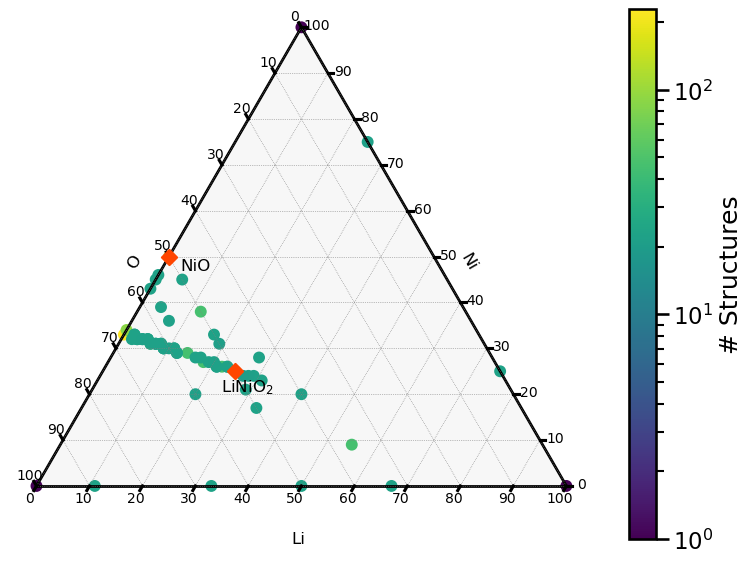

In [34]:
import numpy as np
import ternary
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from ternary.helpers import project_sequence, project_point

# -------------------------------
# Count formulas
# -------------------------------
counts = data["formula_red"].value_counts()
unique_formulas = counts.index.tolist()

def get_fractions(formula):
    f = Formula(formula)
    comp = f.count()
    n_Li = comp.get("Li", 0)
    n_Ni = comp.get("Ni", 0)
    n_O  = comp.get("O", 0)
    total = n_Li + n_Ni + n_O
    return n_Li/total, n_Ni/total, n_O/total

# Build points + colors
points = []
colors = []
for fmla in unique_formulas:
    l, n, o = get_fractions(fmla)
    points.append((l, n, o))
    colors.append(int(counts[fmla]))

# -------------------------------
# Ternary plot scaffold
# -------------------------------
scale = 100
points_scaled = [(int(round(l*scale)), int(round(n*scale)), int(round(o*scale)))
                 for l, n, o in points]

fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 6)

tax.boundary(linewidth=2)
tax.gridlines(multiple=10, color="gray")

tax.left_axis_label("O", fontsize=12)
tax.right_axis_label("Ni", fontsize=12)
tax.bottom_axis_label("Li", fontsize=12)

tax.ticks(axis='lbr', multiple=10)
tax.clear_matplotlib_ticks()

# -------------------------------
# Scatter (do it on Matplotlib axes directly)
# -------------------------------
ax = tax.get_axes()

# Remove rectangular frame
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove background patch edge
ax.set_frame_on(False)

# Optional: remove axis ticks entirely
ax.set_xticks([])
ax.set_yticks([])


xs, ys = project_sequence(points_scaled, permutation=tax._permutation)

norm = LogNorm(vmin=1, vmax=max(colors))
sc = ax.scatter(
    xs, ys,
    c=colors,
    cmap="viridis",
    norm=norm,
    s=50
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("# Structures")

# -------------------------------
# Annotation helper
# -------------------------------
def annotate_formula(formula, label=None, offset=(8, 6), **text_kwargs):
    if label is None:
        label = formula

    l, n, o = get_fractions(formula)
    p = (int(round(l*scale)), int(round(n*scale)), int(round(o*scale)))

    # mark the point clearly (use Matplotlib scatter to avoid python-ternary vmin/vmax behavior)
    x2d, y2d = project_point(p, permutation=tax._permutation)
    ax.scatter([x2d], [y2d], marker="D", color="orangered", s=60, zorder=5)

    ax.annotate(
        label,
        xy=(x2d, y2d),
        xytext=offset,
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=12,
        color="black",
        **text_kwargs
    )

# annotate phases
annotate_formula("LiNiO2", label="LiNiO$_2$", offset=(-10, -18))
annotate_formula("NiO", label="NiO", offset=(8, -12))

plt.tight_layout()
plt.show()


# add force metrics as columns

In [35]:
def add_force_metrics(df, forces_col="forces"):
    df = df.copy()

    def compute_metrics(F):
        F = np.asarray(F)

        # Per-atom magnitudes
        atom_mags = np.linalg.norm(F, axis=1)

        return {
            # Grace metric (Frobenius norm of whole force matrix)
            "F_frob": float(np.linalg.norm(F)),

            # RMS over all components (same as Frobenius / sqrt(N_atoms*3))
            "F_rms_global": float(np.sqrt(np.mean(F**2))),

            # RMS per atom (size-normalized, good physical scalar)
            "F_rms_atom": float(np.sqrt(np.mean(np.sum(F**2, axis=1)))),

            # Mean per-atom magnitude
            "F_mean_atom": float(atom_mags.mean()),

            # Max per-atom magnitude
            "F_max_atom": float(atom_mags.max()),
        }

    metrics = df[forces_col].apply(compute_metrics)
    metrics_df = pd.DataFrame(metrics.tolist(), index=df.index)

    return pd.concat([df, metrics_df], axis=1)


data = add_force_metrics(data)

data.head()


,name,ase_atoms,energy,forces,stress,results,energy_corrected,energy_corrected_per_atom,type,n_atoms,formula,formula_red,Ni_O_ratio,Li_Ni_ratio,F_frob,F_rms_global,F_rms_atom,F_mean_atom,F_max_atom
0,ce_structures/selected/18_0.375/0000/OUTCAR##0,"(Atom('Li', [np.float64(-2.73936), np.float64(...",-225.506490,"[[0.008302, 0.014337, 6e-05], [1.5e-05, 6e-05,...","[-0.005913505338299842, -0.005637774189645697,...","{'magmom': 3.0, 'magmoms': [0.009, 0.009, 0.00...",-121.388465,-4.495869,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375,0.352129,0.039125,0.067767,0.059063,0.095155
1,ce_structures/selected/18_0.375/s0950_k000/OUT...,"(Atom('Li', [np.float64(1.60487), np.float64(-...",-220.157903,"[[-0.092948, -0.169861, 0.11735], [0.015319, 0...","[-0.2814075827513161, -0.3119029721894691, -0....","{'magmom': 3.0, 'magmoms': [0.009, 0.009, 0.00...",-116.039877,-4.297773,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375,13.141942,1.460216,2.529168,2.152571,3.893078
2,ce_structures/selected/18_0.375/s0950_k001/OUT...,"(Atom('Li', [np.float64(0.05328), np.float64(0...",-212.712001,"[[0.077629, -0.25681, -0.284935], [0.00216, 0....","[-0.541944570110157, -0.652920618375809, -0.39...","{'magmom': 3.0, 'magmoms': [0.011, 0.012, 0.01...",-108.593975,-4.021999,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375,20.440185,2.271132,3.933715,3.350377,6.036925
3,ce_structures/selected/18_0.375/s0960_k000/OUT...,"(Atom('Li', [np.float64(-3.88834), np.float64(...",-209.283534,"[[-0.323024, -0.089433, 0.278154], [0.043983, ...","[-0.7515230245956165, -0.4900357986799055, -0....","{'magmom': 3.0, 'magmoms': [0.01, 0.01, 0.01, ...",-105.165508,-3.895019,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375,29.613612,3.290401,5.699142,4.684109,9.647660
4,ce_structures/selected/18_0.375/s0960_k001/OUT...,"(Atom('Li', [np.float64(0.05249), np.float64(0...",-220.572119,"[[-0.009643, -0.255397, -0.089572], [-0.029939...","[-0.29187823235524274, -0.2374463620683985, -0...","{'magmom': 3.0, 'magmoms': [0.011, 0.011, 0.01...",-116.454094,-4.313115,ce structures,27,Li3Ni8O16,Li3Ni8O16,0.5,0.375,12.596277,1.399586,2.424155,2.090462,3.710680


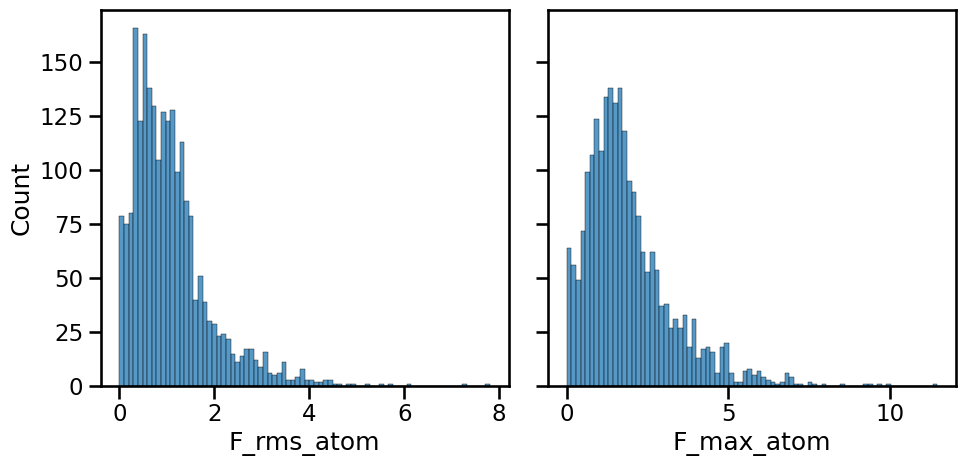

In [36]:
metrics = [
    "F_rms_atom",
    "F_max_atom",
]


fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, col in zip(axes, metrics):
    sns.histplot(data[col], bins=80, kde=False, ax=ax)
    ax.set_xlabel(col)

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

# E-V plots

In [37]:
data["volume"] = data["ase_atoms"].apply(lambda a: a.get_volume())
data["volume_per_atom"] = data["volume"] / data["n_atoms"]

In [38]:
# ignore the atomic references
subset = data.loc[data["volume_per_atom"] <= 700]

In [42]:
from plotly.subplots import make_subplots

# First plot
fig1 = px.scatter(
    subset,
    x="volume_per_atom",
    y="energy_corrected_per_atom",
    color="type",
    hover_data=["formula_red"]
)

# Second plot
fig2 = px.scatter(
    subset,
    x="F_max_atom",
    y="energy_corrected_per_atom",
    color="type",
    hover_data=["formula_red"]
)

# Create subplot canvas
fig = make_subplots(rows=1, cols=2)


# Add traces from first figure (keep legend)
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

# Add traces from second figure (no legend)
for trace in fig2.data:
    trace.showlegend = False
    fig.add_trace(trace, row=1, col=2)

# Optional shared styling
fig.update_traces(
    marker=dict(
        size=5,
        line=dict(width=1, color="gainsboro")
    )
)

fig.update_layout(
    template="ggplot2",
    width=1200,
    height=550
)

fig.update_xaxes(title_text="Volume per atom", row=1, col=1)
fig.update_yaxes(title_text="Energy per atom", row=1, col=1)

fig.update_xaxes(title_text="Force max per atom", row=1, col=2)


fig.show()

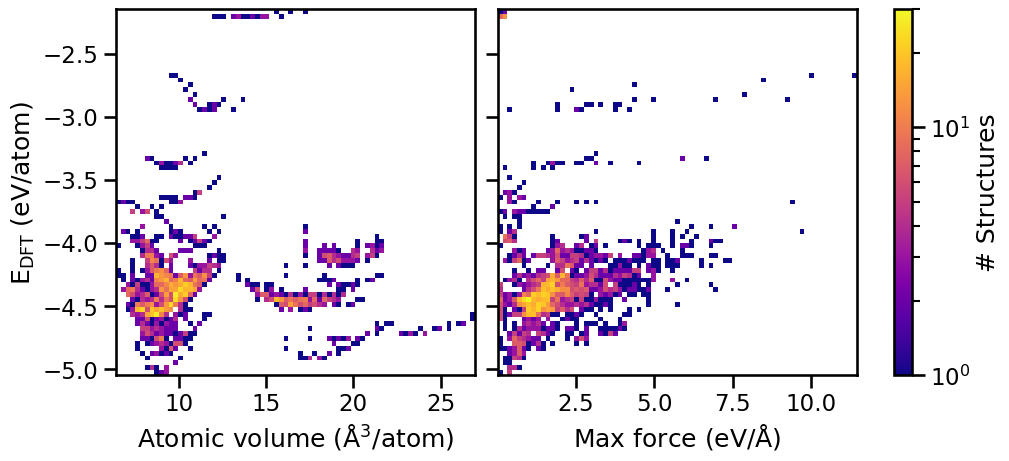

In [40]:
# make sure Frms exists
#if "Frms" not in df.columns:
#    df["Frms"] = df["forces"].apply(
#        lambda F: float(np.sqrt((np.asarray(F)**2).mean()))
#    )

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5),
                         constrained_layout=True, sharey=True)

xbins, ybins = 75, 75

# ---------------------------
# Panel 1: V/atom vs E/atom
# ---------------------------
x1 = subset["volume_per_atom"].to_numpy()
y1 = subset["energy_corrected_per_atom"].to_numpy()

m1 = np.isfinite(x1) & np.isfinite(y1)
x1, y1 = x1[m1], y1[m1]

xlim1 = (np.nanmin(x1), np.nanmax(x1))
ylim  = (np.nanmin(y1), np.nanmax(y1))  # shared y

H1, xedges1, yedges1 = np.histogram2d(
    x1, y1, bins=[xbins, ybins], range=[xlim1, ylim]
)

# ---------------------------
# Panel 2: Frms vs E/atom
# ---------------------------
x2 = subset["F_max_atom"].to_numpy()
y2 = subset["energy_corrected_per_atom"].to_numpy()

m2 = np.isfinite(x2) & np.isfinite(y2)
x2, y2 = x2[m2], y2[m2]

xlim2 = (np.nanmin(x2), np.nanmax(x2))

H2, xedges2, yedges2 = np.histogram2d(
    x2, y2, bins=[xbins, ybins], range=[xlim2, ylim]
)

# -------- shared normalization --------
vmax = max(H1.max(), H2.max(), 1)
norm = LogNorm(vmin=1, vmax=vmax)

# -------- plotting --------
mesh1 = axes[0].pcolormesh(
    xedges1, yedges1, H1.T,
    norm=norm, cmap="plasma", shading="auto"
)
axes[0].set_xlabel(r"Atomic volume ($\mathrm{\AA}^3$/atom)")
axes[0].set_ylabel(r"$\mathrm{E_{DFT}}$ (eV/atom)")
axes[0].set_xlim(*xlim1)
axes[0].set_ylim(*ylim)

mesh2 = axes[1].pcolormesh(
    xedges2, yedges2, H2.T,
    norm=norm, cmap="plasma", shading="auto"
)
axes[1].set_xlabel(r"Max force (eV/$\mathrm{\AA}$)")
axes[1].set_xlim(*xlim2)

# one shared colorbar
cbar = fig.colorbar(mesh1, ax=axes, location="right")
cbar.set_label("# Structures")

plt.show()